In [2]:
import pandas as pd

housing = pd.read_csv('housing.csv')
print(housing.columns)
print(housing.head())
print(housing.shape)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no            

In [3]:
from sklearn.model_selection import train_test_split

X = housing[['area']]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 436
Test size: 109


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (slope): 425.72984193878284
Intercept: 2512254.2639593435


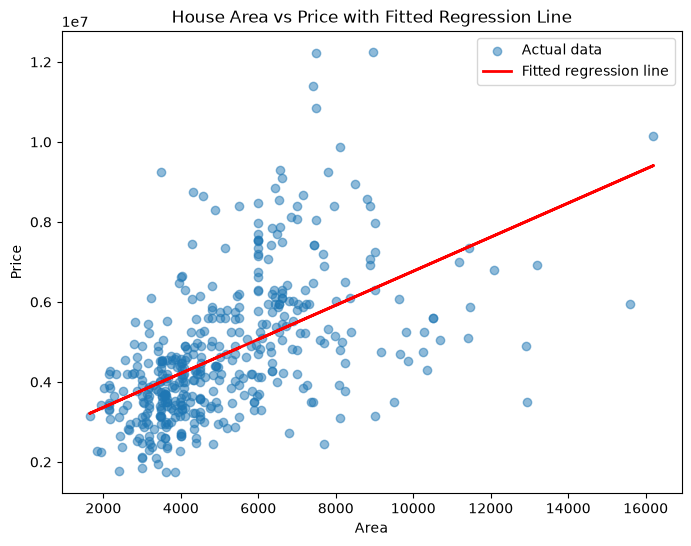

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, alpha=0.5, label='Actual data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Fitted regression line')
plt.title('House Area vs Price with Fitted Regression Line')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.show()

In [6]:
y_pred = model.predict(X_test)

In [7]:
import numpy as np

manual_mse = np.mean((y_test - y_pred) ** 2)
print("Manual MSE:", manual_mse)

Manual MSE: 3675286604768.185


In [8]:
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
manual_r2 = 1 - (ss_res / ss_tot)
print("Manual R²:", manual_r2)

Manual R²: 0.27287851871974644


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

sklearn_mse = mean_squared_error(y_test, y_pred)
sklearn_r2 = r2_score(y_test, y_pred)

print("Sklearn MSE:", sklearn_mse)
print("Sklearn R²:", sklearn_r2)

Sklearn MSE: 3675286604768.185
Sklearn R²: 0.27287851871974644


The slope (425.73) tells us for every extra square foot of area, the price goes up by about 425.73. But the R² (0.27) tells us area alone only explains about 27% of why prices 
differ - so area matters, but a lot of the price difference comes from other things not included in this model